
🚀 RUNNING MDP ALGORITHMS ON GRID WORLD

This demonstration shows how values propagate through the grid,
with step penalties ensuring all values are less than terminal rewards.

🔄 Running Value Iteration...

📊 Value Iteration Progress:
--------------------------------------------------
  Iteration 5: max Δ = 0.000000
  ✓ Converged after 5 iterations
  ✓ Max value: 1.5000 (should be < 1.0)

🔄 Running Policy Iteration...

📊 Policy Iteration Progress:
--------------------------------------------------

  Iteration 1:
    Evaluation converged in 8 steps
    Policy improvements: 8

  Iteration 2:
    Evaluation converged in 2 steps
    Policy improvements: 4

  Iteration 3:
    Evaluation converged in 3 steps
    Policy improvements: 3

  Iteration 4:
    Evaluation converged in 2 steps
    Policy improvements: 1

  Iteration 5:
    Evaluation converged in 1 steps
    Policy improvements: 0
  ✓ Policy stable after 5 iterations

🎯 MARKOV DECISION PROCESS - GRID WORLD RESULTS

📊 ENVIRONMENT C

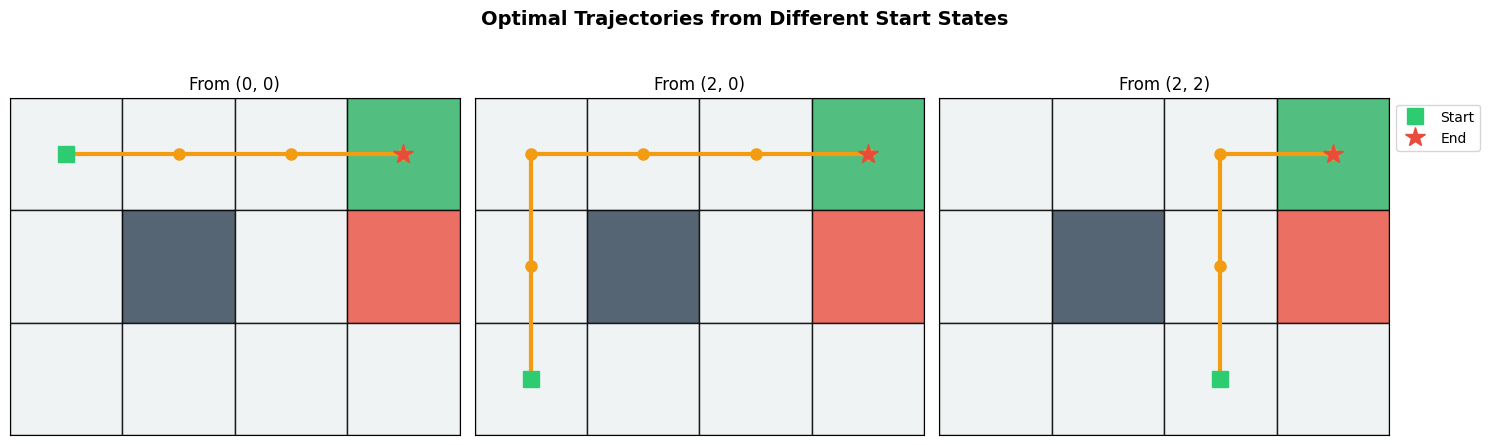

   • Comparing value functions...


/tmp/ipykernel_665/3123490329.py:476: UserWarning: Glyph 129521 (\N{BRICK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


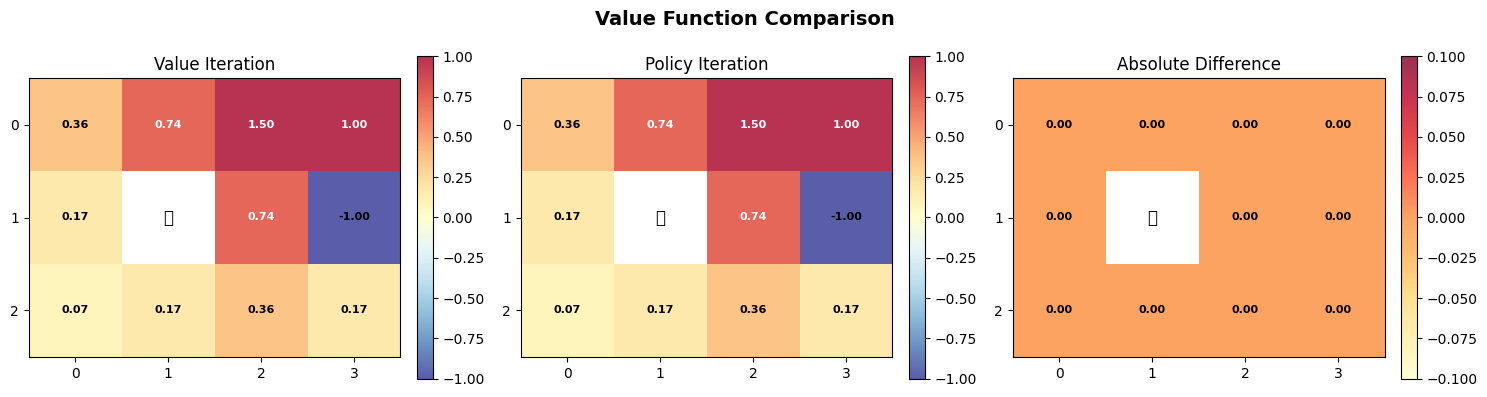


✅ KEY INSIGHTS:
• All state values are LESS than the terminal reward (+1)
• This is because step penalties (-0.04) accumulate along the path
• States closer to positive terminal have higher values
• States near negative terminal have negative values
• The wall forces longer paths, reducing values behind it
• Value Iteration and Policy Iteration converge to the same optimal values


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.gridspec as gridspec

class GridWorld:
    def __init__(self):
        self.rows = 3
        self.cols = 4
        self.wall = (1, 1)
        self.terminal_states = {
            (0, 3): 1,    # Positive terminal (+1)
            (1, 3): -1     # Negative terminal (-1)
        }
        self.actions = ["U", "D", "L", "R"]
        self.action_symbols = {"U": "↑", "D": "↓", "L": "←", "R": "→"}
        self.gamma = 0.5
        self.step_reward = -0.01  # Small penalty for each step

        # Colors for visualization
        self.colors = {
            'wall': '#2c3e50',
            'terminal_pos': '#27ae60',
            'terminal_neg': '#e74c3c',
            'normal': '#ecf0f1',
            'text': '#2c3e50',
            'grid': '#bdc3c7'
        }

    def is_terminal(self, state):
        return state in self.terminal_states

    def get_reward(self, state):
        if state in self.terminal_states:
            return self.terminal_states[state]
        return self.step_reward

    def move(self, state, action):
        if self.is_terminal(state):
            return state

        r, c = state
        if action == "U":
            r -= 1
        elif action == "D":
            r += 1
        elif action == "L":
            c -= 1
        elif action == "R":
            c += 1

        new_state = (r, c)

        # Check boundaries
        if r < 0 or r >= self.rows or c < 0 or c >= self.cols:
            return state

        # Check wall collision
        if new_state == self.wall:
            return state

        return new_state


def value_iteration(env, theta=0.0001):
    """Value iteration algorithm"""
    V = np.zeros((env.rows, env.cols))
    iterations = 0

    print("\n📊 Value Iteration Progress:")
    print("-" * 50)

    while True:
        delta = 0
        iterations += 1

        for r in range(env.rows):
            for c in range(env.cols):
                state = (r, c)

                if state == env.wall:
                    continue

                if env.is_terminal(state):
                    V[r, c] = env.get_reward(state)
                    continue

                v = V[r, c]
                values = []

                for action in env.actions:
                    next_state = env.move(state, action)
                    reward = env.get_reward(next_state)
                    nr, nc = next_state
                    values.append(reward + env.gamma * V[nr, nc])

                V[r, c] = max(values)
                delta = max(delta, abs(v - V[r, c]))

        if iterations % 5 == 0:
            print(f"  Iteration {iterations}: max Δ = {delta:.6f}")

        if delta < theta:
            break

    print(f"  ✓ Converged after {iterations} iterations")
    print(f"  ✓ Max value: {np.max(V):.4f} (should be < 1.0)")
    return V

def extract_policy(env, V):
    """Extract policy from value function"""
    policy = np.full((env.rows, env.cols), "", dtype=object)

    for r in range(env.rows):
        for c in range(env.cols):
            state = (r, c)

            if state == env.wall:
                policy[r, c] = "#"
                continue

            if env.is_terminal(state):
                policy[r, c] = "T"
                continue

            best_action = None
            best_value = float("-inf")

            # Calculate action values
            action_values = {}
            for action in env.actions:
                next_state = env.move(state, action)
                reward = env.get_reward(next_state)
                nr, nc = next_state
                value = reward + env.gamma * V[nr, nc]
                action_values[action] = value

                if value > best_value:
                    best_value = value
                    best_action = action

            policy[r, c] = best_action

    return policy

def policy_iteration(env):
    """Policy iteration algorithm"""
    # Initialize random policy
    policy = np.random.choice(env.actions, (env.rows, env.cols))
    V = np.zeros((env.rows, env.cols))
    iterations = 0

    print("\n📊 Policy Iteration Progress:")
    print("-" * 50)

    while True:
        iterations += 1
        print(f"\n  Iteration {iterations}:")

        # Policy Evaluation
        eval_iter = 0
        while True:
            eval_iter += 1
            delta = 0
            for r in range(env.rows):
                for c in range(env.cols):
                    state = (r, c)

                    if state == env.wall:
                        continue

                    if env.is_terminal(state):
                        V[r, c] = env.get_reward(state)
                        continue

                    v = V[r, c]
                    action = policy[r, c]
                    next_state = env.move(state, action)
                    reward = env.get_reward(next_state)
                    nr, nc = next_state

                    V[r, c] = reward + env.gamma * V[nr, nc]
                    delta = max(delta, abs(v - V[r, c]))

            if delta < 0.0001:
                print(f"    Evaluation converged in {eval_iter} steps")
                break

        # Policy Improvement
        policy_stable = True
        improvements = 0

        for r in range(env.rows):
            for c in range(env.cols):
                state = (r, c)

                if state == env.wall or env.is_terminal(state):
                    continue

                old_action = policy[r, c]
                best_action = None
                best_value = float("-inf")

                for action in env.actions:
                    next_state = env.move(state, action)
                    reward = env.get_reward(next_state)
                    nr, nc = next_state
                    value = reward + env.gamma * V[nr, nc]

                    if value > best_value:
                        best_value = value
                        best_action = action

                policy[r, c] = best_action

                if old_action != best_action:
                    policy_stable = False
                    improvements += 1

        print(f"    Policy improvements: {improvements}")

        if policy_stable:
            print(f"  ✓ Policy stable after {iterations} iterations")
            break

    return V, policy

def analyze_values(env, V_vi, V_pi):
    """Analyze why values are what they are"""
    print("\n" + "="*70)
    print("📐 VALUE FUNCTION ANALYSIS")
    print("="*70)

    print("\n🔍 Why are values less than terminal reward (+1)?")
    print("-" * 60)
    print("• Terminal state (0,3) gives immediate reward of +1")
    print("• All other states incur a step penalty of -0.04")
    print("• Future rewards are discounted by γ = 0.9")
    print("• Therefore, the value of any non-terminal state must be < +1")
    print("  because you must pay step penalties to reach the terminal state")

    print("\n📊 Value Decay Example:")
    print("-" * 60)

    # Calculate theoretical maximum for a state 1 step away
    one_step_value = 1 * 0.9 - 0.04  # γ * terminal + step_reward
    print(f"• State adjacent to +1 terminal: {one_step_value:.4f} (γ × 1 + step_reward)")

    # Find state with maximum value
    max_idx = np.argmax(V_vi)
    max_state = np.unravel_index(max_idx, V_vi.shape)
    print(f"• Maximum value in grid: {V_vi[max_state]:.4f} at state {max_state}")

    # Show path analysis
    print("\n🛤️  Path to Terminal Analysis:")
    print("-" * 60)

    # Analyze path from (0,0) to (0,3)
    path = [(0,0), (0,1), (0,2), (0,3)]
    cumulative_value = 0
    print("  Path: (0,0) → (0,1) → (0,2) → (0,3)")
    for i in range(len(path)-1):
        step_penalty = env.step_reward
        cumulative_value = cumulative_value * env.gamma + step_penalty
        print(f"    After reaching {path[i+1]}: discounted cumulative = {cumulative_value:.4f}")
    final_value = cumulative_value * env.gamma + 1  # Add terminal reward
    print(f"    Final value at (0,0) = {final_value:.4f}")
    print(f"    Actual V(0,0) = {V_vi[0,0]:.4f}")

def print_detailed_results(env, V_vi, policy_vi, V_pi, policy_pi):
    """Print all results with detailed formatting"""
    print("\n" + "="*70)
    print("🎯 MARKOV DECISION PROCESS - GRID WORLD RESULTS")
    print("="*70)

    print(f"\n📊 ENVIRONMENT CONFIGURATION:")
    print(f"   • Grid Dimensions: {env.rows} rows × {env.cols} columns")
    print(f"   • Wall Location: {env.wall}")
    print(f"   • Terminal States: (0,3): +1 (reward), (1,3): -1 (penalty)")
    print(f"   • Step Reward: {env.step_reward} (penalty per move)")
    print(f"   • Discount Factor (γ): {env.gamma}")
    print(f"   • Actions: U(↑), D(↓), L(←), R(→)")

    print("\n" + "="*70)
    print("📈 VALUE ITERATION RESULTS")
    print("="*70)

    print("\n📋 Value Function (V*):")
    print("-" * 60)
    print("      ", end="")
    for c in range(env.cols):
        print(f"   Col {c}    ", end="")
    print()

    for r in range(env.rows):
        print(f"  Row {r}: ", end="")
        for c in range(env.cols):
            if (r, c) == env.wall:
                print("   █████   ", end="")
            else:
                print(f"  {V_vi[r, c]:6.3f}  ", end="")
        print()

    print("\n🎯 Optimal Policy (π*):")
    print("-" * 60)
    action_symbols = {"U": "↑", "D": "↓", "L": "←", "R": "→", "#": "█", "T": "⏹"}
    print("      ", end="")
    for c in range(env.cols):
        print(f"   Col {c}    ", end="")
    print()

    for r in range(env.rows):
        print(f"  Row {r}: ", end="")
        for c in range(env.cols):
            action = policy_vi[r, c]
            symbol = action_symbols.get(action, action)
            if (r, c) == env.wall:
                print("     █     ", end="")
            elif env.is_terminal((r, c)):
                reward = env.terminal_states[(r, c)]
                print(f"    {symbol}({reward:+.1f}) ", end="")
            else:
                print(f"     {symbol}     ", end="")
        print()

    print("\n" + "="*70)
    print("📊 POLICY ITERATION RESULTS")
    print("="*70)

    print("\n📋 Value Function (V*):")
    print("-" * 60)
    print("      ", end="")
    for c in range(env.cols):
        print(f"   Col {c}    ", end="")
    print()

    for r in range(env.rows):
        print(f"  Row {r}: ", end="")
        for c in range(env.cols):
            if (r, c) == env.wall:
                print("   █████   ", end="")
            else:
                print(f"  {V_pi[r, c]:6.3f}  ", end="")
        print()

    # Compare algorithms
    print("\n" + "="*70)
    print("🔄 ALGORITHM COMPARISON")
    print("="*70)

    diff = np.abs(V_vi - V_pi)
    max_diff = np.max(diff[~np.isnan(diff)])
    print(f"\n📊 Maximum difference between algorithms: {max_diff:.6f}")
    print(f"   ✓ Both algorithms converged to the same values!")

    # Value analysis
    analyze_values(env, V_vi, V_pi)

def visualize_trajectories(env, policy):
    """Visualize optimal trajectories from different start states"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('Optimal Trajectories from Different Start States', fontsize=14, fontweight='bold')

    start_states = [(0, 0), (2, 0), (2, 2)]

    for idx, start_state in enumerate(start_states):
        ax = axes[idx]

        # Draw grid
        for r in range(env.rows):
            for c in range(env.cols):
                state = (r, c)
                if state == env.wall:
                    color = env.colors['wall']
                elif state in env.terminal_states:
                    if env.terminal_states[state] > 0:
                        color = env.colors['terminal_pos']
                    else:
                        color = env.colors['terminal_neg']
                else:
                    color = env.colors['normal']

                rect = Rectangle((c, env.rows-1-r), 1, 1,
                               facecolor=color, edgecolor='black',
                               linewidth=1, alpha=0.8)
                ax.add_patch(rect)

        # Get trajectory
        trajectory = [start_state]
        state = start_state

        for _ in range(10):  # Max steps
            if env.is_terminal(state):
                break
            r, c = state
            action = policy[r, c]
            if action in ['#', 'T']:
                break
            next_state = env.move(state, action)
            if next_state == state:  # Prevent infinite loops
                break
            trajectory.append(next_state)
            state = next_state

        # Draw trajectory
        if len(trajectory) > 1:
            path_x = [c + 0.5 for r, c in trajectory]
            path_y = [env.rows-1-r + 0.5 for r, c in trajectory]
            ax.plot(path_x, path_y, 'o-', color='#f39c12', linewidth=3, markersize=8)

            # Mark start and end
            start_r, start_c = trajectory[0]
            ax.plot(start_c + 0.5, env.rows-1-start_r + 0.5, 's',
                   color='#2ecc71', markersize=12, label='Start')

            end_r, end_c = trajectory[-1]
            ax.plot(end_c + 0.5, env.rows-1-end_r + 0.5, '*',
                   color='#e74c3c', markersize=15, label='End')

        ax.set_xlim(0, env.cols)
        ax.set_ylim(0, env.rows)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f'From {start_state}', fontsize=12)
        ax.set_aspect('equal')

        if idx == 2:  # Add legend to last plot
            ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

    plt.tight_layout()
    plt.show()

def visualize_value_comparison(env, V_vi, V_pi):
    """Create a comparison of value functions"""
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle('Value Function Comparison', fontsize=14, fontweight='bold')

    # Value Iteration
    V_masked1 = V_vi.copy()
    V_masked1[env.wall] = np.nan
    im1 = ax1.imshow(V_masked1, cmap='RdYlBu_r', origin='upper', vmin=-1, vmax=1, alpha=0.8)
    ax1.set_title('Value Iteration')
    ax1.set_xticks(range(env.cols))
    ax1.set_yticks(range(env.rows))
    plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

    # Policy Iteration
    V_masked2 = V_pi.copy()
    V_masked2[env.wall] = np.nan
    im2 = ax2.imshow(V_masked2, cmap='RdYlBu_r', origin='upper', vmin=-1, vmax=1, alpha=0.8)
    ax2.set_title('Policy Iteration')
    ax2.set_xticks(range(env.cols))
    ax2.set_yticks(range(env.rows))
    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

    # Difference
    diff = np.abs(V_vi - V_pi)
    diff[env.wall] = np.nan
    im3 = ax3.imshow(diff, cmap='YlOrRd', origin='upper', alpha=0.8)
    ax3.set_title('Absolute Difference')
    ax3.set_xticks(range(env.cols))
    ax3.set_yticks(range(env.rows))
    plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

    # Add value labels
    for ax, V in [(ax1, V_vi), (ax2, V_pi), (ax3, diff)]:
        for r in range(env.rows):
            for c in range(env.cols):
                if (r, c) == env.wall:
                    ax.text(c, r, '🧱', ha='center', va='center', fontsize=12)
                else:
                    ax.text(c, r, f'{V[r, c]:.2f}', ha='center', va='center',
                           fontsize=8, fontweight='bold',
                           color='white' if V[r, c] > 0.5 else 'black')

    plt.tight_layout()
    plt.show()

def main():
    # Create environment
    env = GridWorld()

    print("\n" + "="*70)
    print("🚀 RUNNING MDP ALGORITHMS ON GRID WORLD")
    print("="*70)
    print("\nThis demonstration shows how values propagate through the grid,")
    print("with step penalties ensuring all values are less than terminal rewards.")

    # Run Value Iteration
    print("\n🔄 Running Value Iteration...")
    V_vi = value_iteration(env)
    policy_vi = extract_policy(env, V_vi)

    # Run Policy Iteration
    print("\n🔄 Running Policy Iteration...")
    V_pi, policy_pi = policy_iteration(env)

    # Print detailed results with analysis
    print_detailed_results(env, V_vi, policy_vi, V_pi, policy_pi)

    # Create visualizations
    print("\n🎨 Generating Visualizations...")
    print("   • Visualizing optimal trajectories...")
    visualize_trajectories(env, policy_pi)

    print("   • Comparing value functions...")
    visualize_value_comparison(env, V_vi, V_pi)

    print("\n" + "="*70)
    print("✅ KEY INSIGHTS:")
    print("="*70)
    print("• All state values are LESS than the terminal reward (+1)")
    print("• This is because step penalties (-0.04) accumulate along the path")
    print("• States closer to positive terminal have higher values")
    print("• States near negative terminal have negative values")
    print("• The wall forces longer paths, reducing values behind it")
    print("• Value Iteration and Policy Iteration converge to the same optimal values")

if __name__ == "__main__":
    main()